In [ ]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
"""
Support Ticket Severity Classifier - Training Pipeline
Handles heuristic pseudo-labeling and DeBERTa LoRA fine-tuning.
"""

import os
import re
import sys
import json
import math
import pickle
import argparse
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import resample
from scipy.stats import spearmanr
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

warnings.filterwarnings("ignore")

# --- Configuration & Constants ---
SEED_VAL = 42
BASE_MODEL = "microsoft/deberta-v3-small"

ORDINAL_MAP = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
REVERSE_MAP = {val: key for key, val in ORDINAL_MAP.items()}

# Keyword Patterns
CRITICAL_TERMS = [r'\bphish\w*\b', r'\bfraud\w*\b', r'\bhack\w*\b', r'\bstolen\b', r'\bunauthori[sz]ed\b', r'\bdata\s+breach\b', r'\bransomware\b', r'\bmalware\b', r'\bidentity\s+theft\b', r'\bcompromised\b']
HIGH_TERMS = [r'\bcrash\w*\b', r'\bnot\s+(loading|working|responding|syncing)\b', r'\bcannot\s+(access|log)', r'\boutage\b', r'\blocke?d\s+out\b', r'\bpayment\s+fail\w*\b', r'\bdata\s+loss\b', r'\bbroken\b', r'\berror\b', r'\bdown\b', r'\bunable\s+to\b', r'\bcorrupt\w*\b']
LOW_TERMS = [r'\bhow\s+do\s+i\b', r'\bwhere\s+is\b', r'\bheadquarters\b', r'\broadmap\b', r'\bfeature\s+request\b', r'\bhours\s+of\s+operation\b']
URGENT_TERMS = [r'\bimmediately\b', r'\burgent\b', r'\basap\b', r'\bcritical\b']

CATEGORY_WEIGHTS = {'Fraud': 0.88, 'Technical': 0.52, 'Account': 0.38, 'Billing': 0.30, 'General Inquiry': 0.08}
LEXICAL_CAT_BASES = {'Fraud': 0.82, 'Technical': 0.50, 'Account': 0.36, 'Billing': 0.30, 'General Inquiry': 0.10}

SEVERE_WORDS = set("cannot access locked stolen phishing fraud hacked unauthorized crash error fail broken outage down missing corrupted urgent data loss breach malware ransomware compromised account suspended payment charge suspicious unable sync attack security".split())
ROUTINE_WORDS = set("how where question general inquiry feature request roadmap headquarters information looking update plan curious wondering schedule".split())

# --- Stage 1: Heuristic Processors ---

def evaluate_keywords(record):
    """Calculates an urgency score based on regex pattern matching."""
    combined_text = str(record.get('Ticket_Subject', '') + " " + record.get('Ticket_Description', '')).lower()

    score = 0.0
    for pattern in CRITICAL_TERMS:
        if re.search(pattern, combined_text): score += 0.32
    for pattern in HIGH_TERMS:
        if re.search(pattern, combined_text): score += 0.20
    for pattern in LOW_TERMS:
        if re.search(pattern, combined_text): score -= 0.14
    for pattern in URGENT_TERMS:
        if re.search(pattern, combined_text): score += 0.14

    normalized_text_score = float(np.clip(score / (abs(score) + 3.0 + 1e-9), 0.0, 1.0)) if score != 0 else 0.0
    cat_influence = CATEGORY_WEIGHTS.get(record.get('Issue_Category'), 0.30)

    return float(np.clip(0.60 * normalized_text_score + 0.40 * cat_influence, 0.0, 1.0))

def extract_time_benchmarks(dataframe):
    """Generates median resolution times grouped by category and priority."""
    group_medians = dataframe.groupby(['Issue_Category', 'Priority_Level'])['Resolution_Time_Hours'].median().to_dict()
    global_medians = dataframe.groupby('Priority_Level')['Resolution_Time_Hours'].median().to_dict()
    return group_medians, global_medians

def calculate_time_anomaly(record, group_benchmarks, global_benchmarks):
    """Scores how far the actual resolution time deviates from the expected norm."""
    actual_hours = float(record['Resolution_Time_Hours'])
    current_priority = record['Priority_Level']
    priority_weight = ORDINAL_MAP[current_priority] / 3.0

    expected_hours = group_benchmarks.get((record['Issue_Category'], current_priority),
                                          global_benchmarks.get(current_priority, 36.0))

    time_ratio = actual_hours / max(expected_hours, 1.0)
    log_ratio = float(math.log(max(time_ratio, 0.01)))

    if log_ratio > 0:
        anomaly_signal = priority_weight * float(math.tanh(log_ratio * 0.8))
    else:
        anomaly_signal = (1.0 - priority_weight) * float(math.tanh(-log_ratio * 0.5))

    return float(np.clip(anomaly_signal, 0.0, 1.0))

def compute_lexical_density(record):
    """Analyzes pure word counts for severe vs routine terminology."""
    raw_text = f"{record['Ticket_Subject']} {record['Ticket_Description']}".lower()
    tokens = re.findall(r'\b\w+\b', raw_text)

    if not tokens:
        return 0.3

    word_count = len(tokens)
    severe_ratio = sum(1 for w in tokens if w in SEVERE_WORDS) / word_count
    routine_ratio = sum(1 for w in tokens if w in ROUTINE_WORDS) / word_count

    lexical_val = float(np.clip((severe_ratio * 14.0) - (routine_ratio * 7.0), 0.0, 1.0))
    satisfaction_val = (5.0 - int(record['Satisfaction_Score'])) / 4.0
    category_val = LEXICAL_CAT_BASES.get(record['Issue_Category'], 0.28)

    return float(np.clip((0.45 * lexical_val) + (0.35 * satisfaction_val) + (0.20 * category_val), 0.0, 1.0))

def extract_semantic_clusters(dataframe, export_path):
    """Builds semantic embeddings and clusters them to find latent severity groups."""
    corpus = dataframe.apply(lambda r: f"{r['Ticket_Subject']}. {r['Ticket_Description']} cat:{r['Issue_Category']} ch:{r['Ticket_Channel']}", axis=1).tolist()

    # Embedding generation
    try:
        from sentence_transformers import SentenceTransformer
        encoder = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = encoder.encode(corpus, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    except ImportError:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.decomposition import TruncatedSVD
        from sklearn.preprocessing import normalize
        vectorizer = TfidfVectorizer(max_features=6000, ngram_range=(1, 2), sublinear_tf=True)
        sparse_matrix = vectorizer.fit_transform(corpus)
        embeddings = normalize(TruncatedSVD(n_components=100, random_state=SEED_VAL).fit_transform(sparse_matrix))

    # Dimensionality reduction
    try:
        import umap
        reducer = umap.UMAP(n_components=8, n_neighbors=15, min_dist=0.05, metric='cosine', random_state=SEED_VAL, verbose=False)
        reduced_embeddings = reducer.fit_transform(embeddings)
    except ImportError:
        from sklearn.decomposition import PCA
        n_comps = min(8, embeddings.shape[1] - 1)
        reduced_embeddings = PCA(n_components=n_comps, random_state=SEED_VAL).fit_transform(embeddings)

    # Clustering
    try:
        import hdbscan
        clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=8, metric='euclidean')
        assigned_labels = clusterer.fit_predict(reduced_embeddings)
    except ImportError:
        from sklearn.cluster import KMeans
        clusterer = KMeans(n_clusters=12, random_state=SEED_VAL, n_init=10)
        assigned_labels = clusterer.fit_predict(reduced_embeddings)

    # Scoring clusters
    dataframe['cluster_id'] = assigned_labels
    cluster_means = {
        cid: dataframe[dataframe['cluster_id'] == cid]['priority_numeric'].mean()
        for cid in set(assigned_labels) if cid != -1
    }

    if cluster_means:
        min_val, max_val = min(cluster_means.values()), max(cluster_means.values())
        signals = []
        for cid in assigned_labels:
            if cid == -1:
                signals.append(0.5)
            else:
                score = (cluster_means.get(cid, min_val) - min_val) / (max_val - min_val + 1e-9)
                signals.append(float(np.clip(score, 0.0, 1.0)))
    else:
        signals = [0.5] * len(dataframe)

    np.save(str(export_path / 'emb_reduced.npy'), reduced_embeddings)
    np.save(str(export_path / 'cluster_ids.npy'), assigned_labels)

    return np.array(signals)

def apply_heuristic_fusion(dataframe, export_dir, model_dir):
    """Combines the 4 individual signals using a Logistic Regression model to create the final pseudo-label."""
    signal_cols = ['sig_kw', 'sig_rt', 'sig_lex', 'sig_sem']
    friendly_names = {'sig_kw': 'Keywords', 'sig_rt': 'Time Anomalies', 'sig_lex': 'Lexical/CSAT', 'sig_sem': 'Semantic Group'}

    print("\n--- Evaluating Signal Agreements ---")
    for idx, feature1 in enumerate(signal_cols):
        for feature2 in signal_cols[idx + 1:]:
            bool1 = (dataframe[feature1] >= 0.5).astype(int)
            bool2 = (dataframe[feature2] >= 0.5).astype(int)
            kappa = cohen_kappa_score(bool1, bool2)
            match_pct = (bool1 == bool2).mean() * 100
            print(f"[{friendly_names[feature1]:<15} & {friendly_names[feature2]:<15}] Kappa: {kappa:.3f} | Match: {match_pct:.1f}%")

    stats_report = {}
    print("\n--- Feature Correlation ---")
    for feature in signal_cols:
        corr_rho, _ = spearmanr(dataframe[feature], dataframe['priority_numeric'])

        # Calculate how often the signal gets the priority within +/- 1 level
        quantized = dataframe[feature].apply(lambda v: 3 if v >= 0.75 else (2 if v >= 0.50 else (1 if v >= 0.25 else 0)))
        accuracy_at_1 = ((quantized - dataframe['priority_numeric']).abs() <= 1).mean()

        stats_report[friendly_names[feature]] = {'spearman_rho': round(corr_rho, 4), 'acc_within_1': round(accuracy_at_1, 4)}
        print(f"{friendly_names[feature]:<18} Rho: {corr_rho:.3f} | Acc@1: {accuracy_at_1 * 100:.1f}%")

    features_matrix = dataframe[signal_cols].values
    target_vector = (dataframe['priority_numeric'] >= 2).astype(int).values

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_matrix)

    classifier = LogisticRegression(C=1.0, class_weight='balanced', max_iter=500, random_state=SEED_VAL)
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_VAL)

    acc_scores = cross_val_score(classifier, scaled_features, target_vector, cv=kfold, scoring='accuracy')
    f1_scores = cross_val_score(classifier, scaled_features, target_vector, cv=kfold, scoring='f1_macro')

    print(f"\nFusion Classifier CV -> Accuracy: {acc_scores.mean():.3f} (±{acc_scores.std():.3f}) | F1: {f1_scores.mean():.3f} (±{f1_scores.std():.3f})")

    classifier.fit(scaled_features, target_vector)
    dataframe['severity_probability'] = classifier.predict_proba(scaled_features)[:, 1]

    feature_weights = dict(zip(signal_cols, np.abs(classifier.coef_[0])))
    weight_sum = sum(feature_weights.values()) + 1e-9

    print("\nFinal Feature Importances:")
    for feature_key, weight_val in sorted(feature_weights.items(), key=lambda item: -item[1]):
        percentage = (weight_val / weight_sum) * 100
        stats_report[friendly_names[feature_key]]['fusion_weight_pct'] = round(percentage, 1)
        print(f"{friendly_names[feature_key]:<18}: {percentage:.1f}%")

    with open(export_dir / 'ablation_table.json', 'w') as jfile:
        json.dump(stats_report, jfile, indent=2)

    with open(model_dir / 'fusion_model.pkl', 'wb') as pfile:
        pickle.dump({'model': classifier, 'scaler': scaler, 'cols': signal_cols}, pfile)

    return dataframe

def tag_data_discrepancies(dataframe):
    """Categorizes tickets based on the delta between assigned and inferred priorities."""
    def convert_score_to_label(score):
        if score >= 0.75: return 'Critical'
        if score >= 0.50: return 'High'
        if score >= 0.25: return 'Medium'
        return 'Low'

    dataframe['calculated_severity'] = dataframe['severity_probability'].apply(convert_score_to_label)
    dataframe['calculated_numeric'] = dataframe['calculated_severity'].map(ORDINAL_MAP)
    dataframe['priority_delta'] = dataframe['calculated_numeric'] - dataframe['priority_numeric']

    # Mark as mismatch if the gap is 2 levels or more
    dataframe['is_mismatch'] = (dataframe['priority_delta'].abs() >= 2).astype(int)

    def determine_mismatch_type(row):
        if row['is_mismatch'] == 0:
            return 'Consistent'
        return 'Hidden Crisis' if row['priority_delta'] >= 2 else 'False Alarm'

    dataframe['discrepancy_type'] = dataframe.apply(determine_mismatch_type, axis=1)

    print(f"\nOverall Discrepancy Rate: {dataframe['is_mismatch'].mean() * 100:.1f}%")
    print("Breakdown:")
    print(dataframe['discrepancy_type'].value_counts().to_string())

    return dataframe

def execute_phase_one(dataset_path, export_dir, model_dir):
    print("=" * 60)
    print(" PHASE 1: GENERATING HEURISTIC PSEUDO-LABELS")
    print("=" * 60)

    dataset = pd.read_csv(dataset_path)
    dataset['priority_numeric'] = dataset['Priority_Level'].map(ORDINAL_MAP)
    print(f"Imported {len(dataset):,} raw records.")

    print("=> Processing Rule-Based Keywords...")
    dataset['sig_kw'] = dataset.apply(evaluate_keywords, axis=1)

    print("=> Processing Resolution Time Deviations...")
    grouped_b, global_b = extract_time_benchmarks(dataset)
    dataset['sig_rt'] = dataset.apply(lambda r: calculate_time_anomaly(r, grouped_b, global_b), axis=1)

    print("=> Processing Lexical & CSAT Context...")
    dataset['sig_lex'] = dataset.apply(compute_lexical_density, axis=1)

    print("=> Processing Semantic Clustering Space...")
    dataset['sig_sem'] = extract_semantic_clusters(dataset, export_dir)

    dataset = apply_heuristic_fusion(dataset, export_dir, model_dir)
    dataset = tag_data_discrepancies(dataset)

    output_file = export_dir / 'labeled_tickets.csv'
    dataset.to_csv(output_file, index=False)
    print(f"\nPhase 1 Complete. Dataset saved to {output_file}")

    return dataset

# --- Stage 2: Deep Learning Training ---

def categorise_time(hours):
    if hours <= 10: return 'FAST'
    if hours <= 45: return 'MID'
    return 'SLOW'

def format_text_prompt(record):
    """Formats the structured data into a prompt for the language model."""
    res_time = float(record.get('Resolution_Time_Hours', 30.0))
    time_bracket = categorise_time(res_time)

    return (f"[SUBJ] {record['Ticket_Subject']} "
            f"[BODY] {record['Ticket_Description']} "
            f"| cat:{record['Issue_Category']} "
            f"| ch:{record['Ticket_Channel']} "
            f"| rt:{time_bracket} "
            f"| pri:{record['Priority_Level']}")

class SupportTicketDataset(Dataset):
    def __init__(self, raw_texts, target_labels, tokenizer):
        self.encodings = tokenizer(
            list(raw_texts),
            truncation=True,
            padding='max_length',
            max_length=256,
            return_tensors='pt'
        )
        self.labels = torch.tensor(target_labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {key: tensor[index] for key, tensor in self.encodings.items()}
        item['labels'] = self.labels[index]
        return item

def evaluate_model(model_obj, dataloader, hardware_device, prob_threshold=0.5):
    """Helper function to run inference on a validation/test dataloader."""
    model_obj.eval()
    all_probabilities, all_targets = [], []

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch['input_ids'].to(hardware_device)
            masks = batch['attention_mask'].to(hardware_device)
            outputs = model_obj(input_ids=inputs, attention_mask=masks)

            # Extract probability for the positive class (Mismatch)
            probs = torch.softmax(outputs.logits.float(), dim=-1)[:, 1].cpu().tolist()
            all_probabilities.extend(probs)
            all_targets.extend(batch['labels'].tolist())

    prob_array = np.array(all_probabilities)
    target_array = np.array(all_targets)
    predictions = (prob_array >= prob_threshold).astype(int)

    acc = accuracy_score(target_array, predictions)
    macro_f1 = f1_score(target_array, predictions, average='macro', zero_division=0)
    class_f1 = f1_score(target_array, predictions, average=None, zero_division=0)

    return acc, macro_f1, class_f1, prob_array, target_array

def execute_phase_two(dataset, model_path, total_epochs, batch_capacity):
    print("\n" + "=" * 60)
    print(" PHASE 2: DEBERTA-V3 FINE-TUNING VIA LORA")
    print("=" * 60)

    hardware = 'cuda' if torch.cuda.is_available() else 'cpu'
    if hardware == 'cuda':
        print(f"Hardware utilized: GPU | {torch.cuda.get_device_name(0)}")
    else:
        print("Hardware utilized: CPU")

    text_columns = ['Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Ticket_Channel', 'Priority_Level']
    for col in text_columns:
        dataset[col] = dataset[col].astype(str)

    dataset['model_input'] = dataset.apply(format_text_prompt, axis=1)
    features = dataset['model_input'].values
    targets = dataset['is_mismatch'].values.astype(int)

    # Standard split: Train, Val, Test
    x_temp, x_test, y_temp, y_test = train_test_split(features, targets, test_size=0.10, stratify=targets, random_state=SEED_VAL)
    x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=SEED_VAL)

    # Class balancing via upsampling the minority class
    x_majority = x_train[y_train == 0]
    y_majority = y_train[y_train == 0]
    x_minority = x_train[y_train == 1]
    y_minority = y_train[y_train == 1]

    upsample_count = len(x_majority) // 3
    x_min_upsampled = resample(x_minority, n_samples=upsample_count, replace=True, random_state=SEED_VAL)

    x_balanced = np.concatenate([x_majority, x_min_upsampled])
    y_balanced = np.concatenate([y_majority, np.ones(upsample_count, dtype=int)])

    # Shuffle the balanced dataset
    shuffler = np.random.RandomState(SEED_VAL)
    shuffle_indices = shuffler.permutation(len(x_balanced))
    x_balanced, y_balanced = x_balanced[shuffle_indices], y_balanced[shuffle_indices]

    print(f"\nData Splits -> Train: {len(x_balanced):,} | Val: {len(x_val):,} | Test: {len(x_test):,}")
    print(f"Balanced Breakdown -> Consistent: {(y_balanced == 0).sum():,} | Mismatch: {(y_balanced == 1).sum():,}")

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    train_data = SupportTicketDataset(x_balanced, y_balanced, tokenizer)
    val_data = SupportTicketDataset(x_val, y_val, tokenizer)
    test_data = SupportTicketDataset(x_test, y_test, tokenizer)

    train_loader = DataLoader(train_data, batch_size=batch_capacity, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32)
    test_loader = DataLoader(test_data, batch_size=32)

    # Setup foundation model and LoRA adapter
    foundation_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2, ignore_mismatched_sizes=True)

    lora_settings = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        bias='none',
        target_modules=['query_proj', 'key_proj', 'value_proj', 'out_proj'],
        modules_to_save=['classifier', 'pooler']
    )

    active_model = get_peft_model(foundation_model, lora_settings).float().to(hardware)
    params_trainable, params_total = active_model.get_nb_trainable_parameters()
    print(f"\nParameters: {params_trainable:,} trainable out of {params_total:,} ({100 * params_trainable / params_total:.2f}%)")

    # Dynamic class weighting
    count_0 = (y_balanced == 0).sum()
    count_1 = (y_balanced == 1).sum()
    total_count = len(y_balanced)

    class_weights = torch.tensor([total_count / (2 * count_0), total_count / (2 * count_1)], dtype=torch.float).to(hardware)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Training configuration
    GRADIENT_ACCUMULATION = 2
    LEARNING_RATE = 3e-5
    total_optimization_steps = (len(train_loader) // GRADIENT_ACCUMULATION) * total_epochs
    warmup_steps = int(0.06 * total_optimization_steps)

    optimizer = AdamW(active_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    lr_scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_optimization_steps)

    print(f"\nConfig: {total_epochs} Epochs | Batch: {batch_capacity} | Accumulation: {GRADIENT_ACCUMULATION} | LR: {LEARNING_RATE}")
    print("-" * 50)
    print(f"{'Epoch':<6} | {'Avg Loss':<10} | {'Val Acc':<10} | {'Val F1':<10}")
    print("-" * 50)

    top_f1 = 0.0
    top_epoch = 0
    training_history = {'loss': [], 'val_f1': []}

    optimizer.zero_grad()

    # Training Loop
    for current_epoch in range(1, total_epochs + 1):
        active_model.train()
        running_loss = 0.0

        for step, batch_data in enumerate(train_loader, start=1):
            inputs_gpu = batch_data['input_ids'].to(hardware)
            masks_gpu = batch_data['attention_mask'].to(hardware)
            labels_gpu = batch_data['labels'].to(hardware)

            predictions = active_model(input_ids=inputs_gpu, attention_mask=masks_gpu)
            loss = criterion(predictions.logits.float(), labels_gpu) / GRADIENT_ACCUMULATION

            loss.backward()
            running_loss += loss.item() * GRADIENT_ACCUMULATION

            if step % GRADIENT_ACCUMULATION == 0:
                nn.utils.clip_grad_norm_(active_model.parameters(), max_norm=1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

        # Validation step
        v_acc, v_f1, _, _, _ = evaluate_model(active_model, val_loader, hardware)
        avg_train_loss = running_loss / len(train_loader)

        training_history['loss'].append(avg_train_loss)
        training_history['val_f1'].append(v_f1)

        print(f" {current_epoch:<5} |  {avg_train_loss:<9.4f} |  {v_acc * 100:<7.2f}%  |  {v_f1:<8.4f}")

        # Save best weights
        if v_f1 > top_f1:
            top_f1 = v_f1
            top_epoch = current_epoch
            active_model.save_pretrained(str(model_path / 'best'))
            tokenizer.save_pretrained(str(model_path / 'best'))

    print(f"\n--- Training Complete. Best Epoch: {top_epoch} (F1: {top_f1:.4f}) ---")

    # Load best weights for threshold tuning and final testing
    best_foundation = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2, ignore_mismatched_sizes=True)
    optimal_model = PeftModel.from_pretrained(best_foundation, str(model_path / 'best')).float().to(hardware)

    # Threshold optimization
    _, _, _, val_probs, val_labels = evaluate_model(optimal_model, val_loader, hardware)
    optimal_threshold = 0.50
    highest_search_f1 = 0.0

    for candidate_thresh in np.linspace(0.20, 0.80, 61):
        temp_preds = (val_probs >= candidate_thresh).astype(int)
        temp_f1 = f1_score(val_labels, temp_preds, average='macro', zero_division=0)
        if temp_f1 > highest_search_f1:
            highest_search_f1 = temp_f1
            optimal_threshold = candidate_thresh

    print(f"\nOptimized Decision Boundary: {optimal_threshold:.2f} (Yields Validation F1: {highest_search_f1:.4f})")

    # Final Test Set Evaluation
    _, _, _, test_probs, test_labels = evaluate_model(optimal_model, test_loader, hardware)
    final_predictions = (test_probs >= optimal_threshold).astype(int)

    t_acc = accuracy_score(test_labels, final_predictions)
    t_f1 = f1_score(test_labels, final_predictions, average='macro', zero_division=0)
    conf_mat = confusion_matrix(test_labels, final_predictions)
    recalls = conf_mat.diagonal() / conf_mat.sum(axis=1)

    print(f"\n--- FINAL TEST RESULTS (Threshold = {optimal_threshold:.2f}) ---")
    print(classification_report(test_labels, final_predictions, target_names=['Consistent', 'Mismatch'], zero_division=0))
    print(f"Overall Accuracy:  {t_acc * 100:.2f}%  {'[PASS]' if t_acc >= 0.83 else '[FAIL]'}")
    print(f"Macro F1 Score:    {t_f1:.4f}     {'[PASS]' if t_f1 >= 0.82 else '[FAIL]'}")
    print(f"Recall Consistent: {recalls[0]:.4f}     {'[PASS]' if recalls[0] >= 0.78 else '[FAIL]'}")
    print(f"Recall Mismatch:   {recalls[1]:.4f}     {'[PASS]' if recalls[1] >= 0.78 else '[FAIL]'}")

    # Final saving
    active_model.save_pretrained(str(model_path))
    tokenizer.save_pretrained(str(model_path))
    np.save(str(model_path / 'threshold.npy'), np.array([optimal_threshold]))

    run_metrics = {
        'accuracy': t_acc,
        'macro_f1': t_f1,
        'recall_consistent': float(recalls[0]),
        'recall_mismatch': float(recalls[1]),
        'threshold': float(optimal_threshold),
        'confusion_matrix': conf_mat.tolist(),
        'best_epoch': top_epoch,
        'history': training_history,
    }

    with open(model_path / 'metrics.json', 'w') as mf:
        json.dump(run_metrics, mf, indent=2)

    print(f"Models and metrics successfully persisted to: {model_path}")

def run_application():
    parser = argparse.ArgumentParser(description="Customer Support Severity Assessment Pipeline")
    parser.add_argument('--data', default='/content/customer_support_tickets.csv', help="Path to input raw dataset")
    parser.add_argument('--output-dir', default='outputs', help="Directory for generated datasets and logs")
    parser.add_argument('--model-dir', default='models/sia_model', help="Directory to save PyTorch models")
    parser.add_argument('--epochs', type=int, default=6, help="Training cycles")
    parser.add_argument('--batch-size', type=int, default=16, help="Data per batch")
    parser.add_argument('--skip-stage1', action='store_true', help="Bypass heuristics if pseudolabels already exist")

    # Passed empty array so this runs smoothly in notebooks without pulling sys.argv
    args = parser.parse_args(args=[])

    out_folder = Path(args.output_dir)
    mod_folder = Path(args.model_dir)

    out_folder.mkdir(parents=True, exist_ok=True)
    mod_folder.mkdir(parents=True, exist_ok=True)
    (mod_folder / 'best').mkdir(exist_ok=True)

    if args.skip_stage1:
        target_csv = out_folder / 'labeled_tickets.csv'
        if not target_csv.exists():
            sys.exit(f"Error: {target_csv} does not exist. Please run without --skip-stage1 first.")
        dataframe = pd.read_csv(target_csv)
    else:
        input_data_path = Path(args.data)
        if not input_data_path.exists():
            sys.exit(f"Error: Dataset {input_data_path} not found. Please verify the path.")
        dataframe = execute_phase_one(input_data_path, out_folder, mod_folder)

    execute_phase_two(dataframe, mod_folder, args.epochs, args.batch_size)
    print("\n[✔] Execution workflow finished successfully.")

if __name__ == '__main__':
    run_application()

 PHASE 1: GENERATING HEURISTIC PSEUDO-LABELS
Imported 20,000 raw records.
=> Processing Rule-Based Keywords...
=> Processing Resolution Time Deviations...
=> Processing Lexical & CSAT Context...
=> Processing Semantic Clustering Space...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]


--- Evaluating Signal Agreements ---
[Keywords        & Time Anomalies ] Kappa: 0.000 | Match: 86.1%
[Keywords        & Lexical/CSAT   ] Kappa: 0.000 | Match: 67.3%
[Keywords        & Semantic Group ] Kappa: 0.000 | Match: 91.1%
[Time Anomalies  & Lexical/CSAT   ] Kappa: -0.002 | Match: 62.4%
[Time Anomalies  & Semantic Group ] Kappa: 0.034 | Match: 80.4%
[Lexical/CSAT    & Semantic Group ] Kappa: 0.108 | Match: 68.1%

--- Feature Correlation ---
Keywords           Rho: 0.405 | Acc@1: 80.3%
Time Anomalies     Rho: 0.179 | Acc@1: 77.2%
Lexical/CSAT       Rho: 0.205 | Acc@1: 80.6%
Semantic Group     Rho: 0.415 | Acc@1: 89.2%

Fusion Classifier CV -> Accuracy: 0.735 (±0.005) | F1: 0.686 (±0.006)

Final Feature Importances:
Semantic Group    : 56.4%
Keywords          : 33.7%
Time Anomalies    : 6.0%
Lexical/CSAT      : 3.9%

Overall Discrepancy Rate: 10.0%
Breakdown:
discrepancy_type
Consistent       17998
Hidden Crisis     1583
False Alarm        419

Phase 1 Complete. Dataset saved to o

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.de


Parameters: 1,034,498 trainable out of 142,930,948 (0.72%)

Config: 6 Epochs | Batch: 16 | Accumulation: 2 | LR: 3e-05
--------------------------------------------------
Epoch  | Avg Loss   | Val Acc    | Val F1    
--------------------------------------------------
 1     |  0.6019    |  85.99  %  |  0.7176  
 2     |  0.2978    |  96.85  %  |  0.9021  
 3     |  0.2542    |  93.29  %  |  0.8372  
 4     |  0.2329    |  92.99  %  |  0.8360  
 5     |  0.2224    |  92.54  %  |  0.8282  
 6     |  0.2199    |  92.39  %  |  0.8263  

--- Training Complete. Best Epoch: 2 (F1: 0.9021) ---


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.de


Optimized Decision Boundary: 0.80 (Yields Validation F1: 0.9069)

--- FINAL TEST RESULTS (Threshold = 0.80) ---
              precision    recall  f1-score   support

  Consistent       0.97      1.00      0.99      1800
    Mismatch       0.97      0.76      0.85       200

    accuracy                           0.97      2000
   macro avg       0.97      0.88      0.92      2000
weighted avg       0.97      0.97      0.97      2000

Overall Accuracy:  97.30%  [PASS]
Macro F1 Score:    0.9167     [PASS]
Recall Consistent: 0.9972     [PASS]
Recall Mismatch:   0.7550     [FAIL]
Models and metrics successfully persisted to: models/sia_model

[✔] Execution workflow finished successfully.


In [9]:
import argparse, json, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

PMAP  = {'Low':0,'Medium':1,'High':2,'Critical':3}
RPMAP = {v:k for k,v in PMAP.items()}
BASE  = "microsoft/deberta-v3-small"

REQUIRED = ['Ticket_ID','Ticket_Subject','Ticket_Description','Issue_Category',
            'Priority_Level','Ticket_Channel','Resolution_Time_Hours','Satisfaction_Score']

ESCA_EV = [
    (r'\bfraud\w*\b',               'fraud_indicator',    0.35),
    (r'\bphish\w*\b',               'security_threat',    0.35),
    (r'\bhack\w*\b',                'security_threat',    0.30),
    (r'\bstolen\b',                 'security_threat',    0.30),
    (r'\bunauthori[sz]ed\b',        'security_threat',    0.28),
    (r'\bdata\s+breach\b',          'data_risk',          0.32),
    (r'\bdata\s+loss\b',            'data_risk',          0.30),
    (r'\bcrash\w*\b',               'system_failure',     0.22),
    (r'\bnot\s+(loading|working|responding)\b', 'functional_failure', 0.20),
    (r'\blocke?d\s+out\b',          'access_blocked',     0.24),
    (r'\bpayment\s+fail\w*\b',      'payment_failure',    0.22),
    (r'\bcompromised\b',            'account_risk',       0.28),
    (r'\bimmediately\b',            'urgency',            0.14),
    (r'\burgent\b',                 'urgency',            0.14),
    (r'\bransomware\b',             'security_threat',    0.40),
    (r'\bmalware\b',                'security_threat',    0.38),
]
DEESC_EV = [
    (r'\bhow\s+do\s+i\b',     'informational', -0.14),
    (r'\bwhere\s+is\b',       'informational', -0.14),
    (r'\bfeature\s+request\b','feature_req',   -0.16),
    (r'\bheadquarters\b',     'general_query', -0.20),
    (r'\broadmap\b',          'general_query', -0.16),
]
RT_BENCH = {
    ('Fraud','Critical'):4,    ('Fraud','High'):12,    ('Fraud','Medium'):28,
    ('Technical','Critical'):5,('Technical','High'):18,('Technical','Medium'):38, ('Technical','Low'):50,
    ('Billing','Critical'):6,  ('Billing','High'):20,  ('Billing','Medium'):42,   ('Billing','Low'):52,
    ('Account','High'):22,     ('Account','Medium'):40,('Account','Low'):50,
    ('General Inquiry','Medium'):35, ('General Inquiry','Low'):45,
}
CAT_SEV = {
    'Fraud':          {'exp':'Critical','w':0.28,'note':'Fraud carries inherent security risk'},
    'Technical':      {'exp':'High',    'w':0.18,'note':'Technical failures impact availability'},
    'Account':        {'exp':'Medium',  'w':0.12,'note':'Account issues affect user access'},
    'Billing':        {'exp':'Medium',  'w':0.10,'note':'Billing issues have financial impact'},
    'General Inquiry':{'exp':'Low',     'w':-0.15,'note':'General inquiries are informational'},
}

def rt_tier(h):
    if h<=10: return 'FAST'
    if h<=45: return 'MID'
    return 'SLOW'

def make_input(row):
    rt = float(row.get('Resolution_Time_Hours', 30))
    return (f"[SUBJ] {row['Ticket_Subject']} "
            f"[BODY] {row['Ticket_Description']} "
            f"| cat:{row['Issue_Category']} "
            f"| ch:{row['Ticket_Channel']} "
            f"| rt:{rt_tier(rt)} "
            f"| pri:{row['Priority_Level']}")

def load_model(mdl_dir, device):
    best = mdl_dir/'best'
    if not best.exists():
        sys.exit(f"No model at {best}. Run train_pipeline.py first.")
    tok   = AutoTokenizer.from_pretrained(str(best))
    base  = AutoModelForSequenceClassification.from_pretrained(BASE, num_labels=2, ignore_mismatched_sizes=True)
    model = PeftModel.from_pretrained(base, str(best)).float().to(device)
    model.eval()
    tf = mdl_dir/'threshold.npy'
    thr = float(np.load(str(tf))[0]) if tf.exists() else 0.5
    return tok, model, thr

def infer_batch(texts, tok, model, device, bs=64):
    probs = []
    for i in range(0, len(texts), bs):
        enc = tok(texts[i:i+bs], truncation=True, padding='max_length',
                  max_length=256, return_tensors='pt')
        enc = {k:v.to(device) for k,v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        probs += torch.softmax(out.logits.float(), -1)[:,1].cpu().tolist()
    return np.array(probs)

def dir_score(row):
    t   = f"{row['Ticket_Subject']} {row['Ticket_Description']}".lower()
    s   = sum(w for _,_,w in ESCA_EV+DEESC_EV if re.search(_,t))
    cat = row['Issue_Category']; pri = row['Priority_Level']
    cs  = CAT_SEV.get(cat, {'exp':'Medium','w':0.05})
    if PMAP.get(cs['exp'],1) > PMAP.get(pri,1): s += abs(cs['w'])
    elif PMAP.get(cs['exp'],1) < PMAP.get(pri,1): s -= abs(cs['w'])
    sat = int(row['Satisfaction_Score'])
    if sat<=2 and pri in ('Low','Medium'): s+=0.18
    elif sat>=4 and pri in ('Critical','High'): s-=0.12
    rt  = float(row['Resolution_Time_Hours'])
    exp = RT_BENCH.get((cat,pri), 40.0)
    r   = rt/max(exp,1)
    if r<0.4: s+=0.14
    elif r>2.5: s+=0.10
    return s

def get_verdict(row, prob):
    base = PMAP.get(row['Priority_Level'],1)
    d    = dir_score(row)
    if d < 0:
        bump     = 2 if prob>=0.90 else 1
        mtype    = 'False Alarm'
        inf_ord  = max(0, base-bump)
    else:
        bump     = 2 if prob>=0.85 else 1
        mtype    = 'Hidden Crisis'
        inf_ord  = min(3, base+bump)
    return RPMAP[inf_ord], mtype

def ev_text(row, mtype):
    t  = f"{row['Ticket_Subject']} {row['Ticket_Description']}".lower()
    ev = []
    for pat, etype, w in ESCA_EV+DEESC_EV:
        m = re.search(pat, t)
        if m:
            fld = 'Ticket_Subject' if re.search(pat, row['Ticket_Subject'].lower()) else 'Ticket_Description'
            ev.append({'signal':'keyword','type':etype,'value':m.group(0),'source_field':fld,'weight':round(w,3)})
    ev = [e for e in ev if (e['weight']>0) == (mtype=='Hidden Crisis')]
    return ev

def ev_rt(row, mtype):
    rt   = float(row['Resolution_Time_Hours'])
    cat  = row['Issue_Category']; pri = row['Priority_Level']
    exp  = RT_BENCH.get((cat,pri), 40.0)
    r    = rt/max(exp,1)
    if r<0.4:
        interp = f"Resolved in {rt:.0f}h vs ~{exp:.0f}h expected — {r:.1f}x faster, {'consistent with over-triage' if mtype=='False Alarm' else 'suggests true urgency exceeded the label'}"
        w = 0.25
    elif r>2.5:
        interp = f"Resolved in {rt:.0f}h vs ~{exp:.0f}h expected — {r:.1f}x slower, suggesting under-resourcing"
        w = 0.20
    else:
        interp = f"Resolved in {rt:.0f}h — within normal range for {pri} {cat} (~{exp:.0f}h)"
        w = 0.05
    return {'signal':'resolution_time','value':f"{rt:.0f}h",'expected':f"~{exp:.0f}h",
            'rt_ratio':round(r,2),'source_field':'Resolution_Time_Hours','interpretation':interp,'weight':round(w,3)}

def ev_sat(row, mtype):
    sat = int(row['Satisfaction_Score']); pri = row['Priority_Level']
    if mtype=='Hidden Crisis' and sat<=2 and pri in ('Low','Medium'):
        interp = f"Sat {sat}/5 on {pri} ticket — low satisfaction signals severity beyond assigned level"
        w = 0.18
    elif mtype=='False Alarm' and sat>=4 and pri in ('Critical','High'):
        interp = f"Sat {sat}/5 on {pri} ticket — high satisfaction consistent with over-triage"
        w = 0.12
    else:
        interp = f"Sat {sat}/5 — insufficient signal for {mtype} independently"
        w = 0.02
    return {'signal':'satisfaction_score','value':str(sat),'source_field':'Satisfaction_Score',
            'interpretation':interp,'weight':round(w,3)}

def ev_cat(row, mtype):
    cat = row['Issue_Category']; pri = row['Priority_Level']
    cs  = CAT_SEV.get(cat, {'exp':'Medium','w':0.05,'note':'Standard category'})
    eo  = PMAP.get(cs['exp'],1); po = PMAP.get(pri,1)
    if mtype=='Hidden Crisis' and eo>po:
        interp = f"{cat} warrants {cs['exp']} priority — {pri} is below baseline. {cs['note']}."
        w = abs(cs['w'])
    elif mtype=='False Alarm' and eo<po:
        interp = f"{cat} warrants {cs['exp']} priority — {pri} exceeds baseline. {cs['note']}."
        w = -abs(cs['w'])
    else:
        interp = f"{cat} assigned {pri} — within expected range."
        w = 0.03
    return {'signal':'category_baseline','value':cat,'expected_level':cs['exp'],
            'source_field':'Issue_Category','interpretation':interp,'weight':round(w,3)}

def delta_str(assigned, inferred):
    a = PMAP.get(assigned,1); i = PMAP.get(inferred,1); d = i-a
    if d>0:  return f"+{d} (under-prioritised by {d} level{'s' if d>1 else ''})"
    if d<0:  return f"{d} (over-prioritised by {abs(d)} level{'s' if abs(d)>1 else ''})"
    return "0 (borderline — signal conflict at same ordinal)"

def build_constraint(row, inferred, mtype, ev):
    cat = row['Issue_Category']; ch = row['Ticket_Channel']; pri = row['Priority_Level']
    rt  = float(row['Resolution_Time_Hours']); sat = int(row['Satisfaction_Score'])
    kp  = [e for e in ev if e['signal']=='keyword' and e.get('weight',0)>0]
    kn  = [e for e in ev if e['signal']=='keyword' and e.get('weight',0)<0]
    s1  = (f"This {cat} ticket submitted via {ch} was assigned {pri} priority, "
           f"but the model infers {inferred} severity from its content and metadata.")
    if mtype=='Hidden Crisis' and kp:
        s2 = f"Escalation indicators ({', '.join(repr(e['value']) for e in kp[:2])}) signal urgency beyond the assigned label."
    elif mtype=='False Alarm' and kn:
        s2 = f"Low-severity indicators ({', '.join(repr(e['value']) for e in kn[:2])}) suggest the ticket does not warrant {pri}."
    else:
        s2 = "Semantic patterns and metadata jointly signal a priority mismatch."
    s3 = (f"Resolution in {rt:.0f}h with satisfaction {sat}/5 "
          + ("supports under-prioritisation — earlier escalation would have reduced customer impact."
             if mtype=='Hidden Crisis'
             else f"suggests the issue was less severe than {pri} implies — resources may have been over-allocated."))
    return f"{s1} {s2} {s3}"

def build_dossier(row, prob):
    inferred, mtype = get_verdict(row, prob)
    kev  = ev_text(row, mtype)
    rtev = ev_rt(row, mtype)
    sev  = ev_sat(row, mtype)
    cev  = ev_cat(row, mtype)
    alev = sorted(kev+[rtev,sev,cev], key=lambda x:abs(x.get('weight',0)), reverse=True)
    return {
        'ticket_id':          str(row['Ticket_ID']),
        'assigned_priority':  row['Priority_Level'],
        'inferred_severity':  inferred,
        'mismatch_type':      mtype,
        'severity_delta':     delta_str(row['Priority_Level'], inferred),
        'confidence':         round(float(prob),4),
        'feature_evidence':   alev,
        'constraint_analysis':build_constraint(row, inferred, mtype, alev),
    }

def main():
    p = argparse.ArgumentParser()
    p.add_argument('--input',      required=True)
    p.add_argument('--output',     default='outputs')
    p.add_argument('--model-dir',  default='models/sia_model')
    p.add_argument('--threshold',  type=float, default=None)
    p.add_argument('--batch-size', type=int,   default=64)
    args = p.parse_args()

    out = Path(args.output); out.mkdir(parents=True, exist_ok=True)
    mdl = Path(args.model_dir)
    if not Path(args.input).exists(): sys.exit(f"ERROR: {args.input} not found")

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")

    df = pd.read_csv(args.input)
    miss = [c for c in REQUIRED if c not in df.columns]
    if miss: sys.exit(f"Missing columns: {miss}")
    for c in ['Ticket_Subject','Ticket_Description','Issue_Category','Ticket_Channel','Priority_Level']:
        df[c] = df[c].astype(str)
    print(f"Loaded {len(df):,} tickets")

    tok, model, saved_thr = load_model(mdl, device)
    thr = args.threshold if args.threshold is not None else saved_thr
    print(f"Threshold: {thr:.2f}")

    texts             = df.apply(make_input, axis=1).tolist()
    probs             = infer_batch(texts, tok, model, device, args.batch_size)
    df['prob']        = probs
    df['predicted']   = (probs>=thr).astype(int)
    df['verdict']     = df['predicted'].map({0:'Consistent',1:'Mismatch'})

    n = df['predicted'].sum()
    print(f"Flagged: {n:,}/{len(df):,} ({n/len(df)*100:.1f}%)")

    df[['Ticket_ID','Priority_Level','Issue_Category','prob','predicted','verdict']].to_csv(
        out/'predictions.csv', index=False)
    print(f"Saved: {out/'predictions.csv'}")

    flagged  = df[df['predicted']==1]
    dossiers = [build_dossier(r, r['prob']) for _,r in flagged.iterrows()]
    with open(out/'evidence_dossiers.json','w') as f:
        json.dump(dossiers, f, indent=2)
    print(f"Saved: {len(dossiers):,} dossiers → {out/'evidence_dossiers.json'}")

    hc = sum(1 for d in dossiers if d['mismatch_type']=='Hidden Crisis')
    fa = sum(1 for d in dossiers if d['mismatch_type']=='False Alarm')
    print(f"HC={hc:,}  FA={fa:,}")
    print("✓ Done")

def main():
    p = argparse.ArgumentParser()

    p.add_argument('--input',       default='/content/customer_support_tickets.csv')
    p.add_argument('--output',      default='outputs')
    p.add_argument('--model-dir',   default='models/sia_model')
    p.add_argument('--threshold',   type=float, default=None)
    p.add_argument('--batch-size',  type=int,   default=64)

    # Colab mein bina error run karne ke liye args=[]
    args = p.parse_args(args=[])

    out = Path(args.output); out.mkdir(parents=True, exist_ok=True)
    mdl = Path(args.model_dir)
    if not Path(args.input).exists(): sys.exit(f"ERROR: {args.input} not found")

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")

    df = pd.read_csv(args.input)
    miss = [c for c in REQUIRED if c not in df.columns]
    if miss: sys.exit(f"Missing columns: {miss}")
    for c in ['Ticket_Subject','Ticket_Description','Issue_Category','Ticket_Channel','Priority_Level']:
        df[c] = df[c].astype(str)
    print(f"Loaded {len(df):,} tickets")

    tok, model, saved_thr = load_model(mdl, device)
    thr = args.threshold if args.threshold is not None else saved_thr
    print(f"Threshold: {thr:.2f}")

    texts             = df.apply(make_input, axis=1).tolist()
    probs             = infer_batch(texts, tok, model, device, args.batch_size)
    df['prob']        = probs
    df['predicted']   = (probs>=thr).astype(int)
    df['verdict']     = df['predicted'].map({0:'Consistent',1:'Mismatch'})

    n = df['predicted'].sum()
    print(f"Flagged: {n:,}/{len(df):,} ({n/len(df)*100:.1f}%)")

    df[['Ticket_ID','Priority_Level','Issue_Category','prob','predicted','verdict']].to_csv(
        out/'predictions.csv', index=False)
    print(f"Saved: {out/'predictions.csv'}")

    flagged  = df[df['predicted']==1]
    dossiers = [build_dossier(r, r['prob']) for _,r in flagged.iterrows()]
    with open(out/'evidence_dossiers.json','w') as f:
        json.dump(dossiers, f, indent=2)
    print(f"Saved: {len(dossiers):,} dossiers → {out/'evidence_dossiers.json'}")

    hc = sum(1 for d in dossiers if d['mismatch_type']=='Hidden Crisis')
    fa = sum(1 for d in dossiers if d['mismatch_type']=='False Alarm')
    print(f"HC={hc:,}  FA={fa:,}")
    print("✓ Done")

if __name__ == '__main__':
    main()


Device: cuda
Loaded 20,000 tickets


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.de

Threshold: 0.80
Flagged: 1,559/20,000 (7.8%)
Saved: outputs/predictions.csv
Saved: 1,559 dossiers → outputs/evidence_dossiers.json
HC=1,170  FA=389
✓ Done


/tmp/ipykernel_7850/2458060941.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights, y=features, palette="viridis")


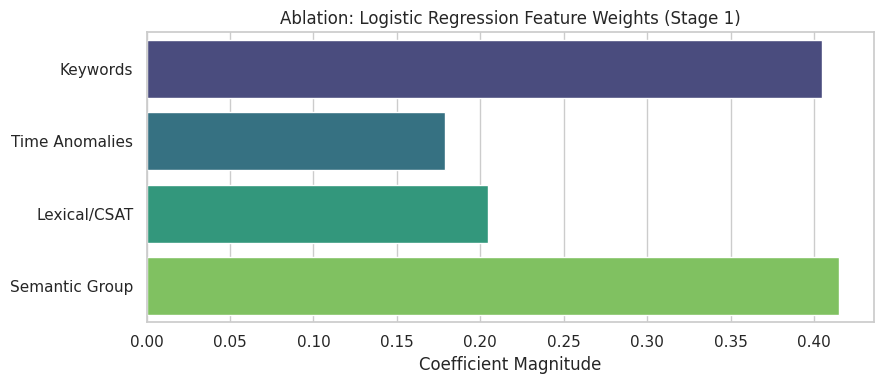

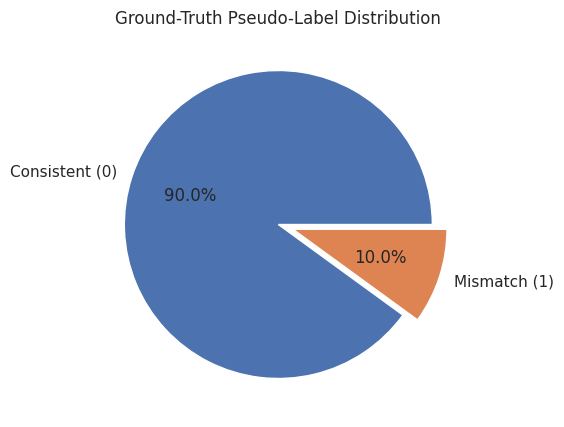

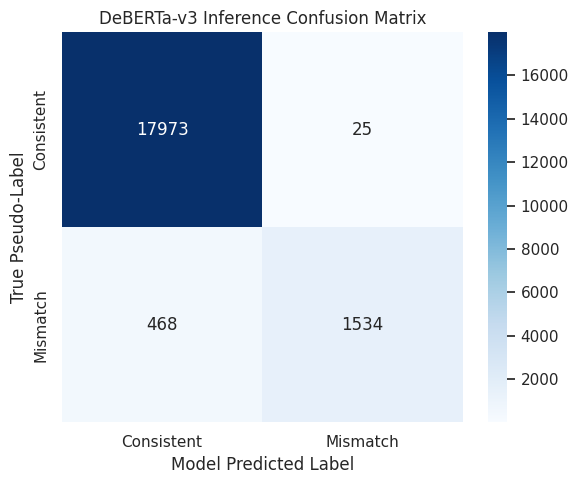

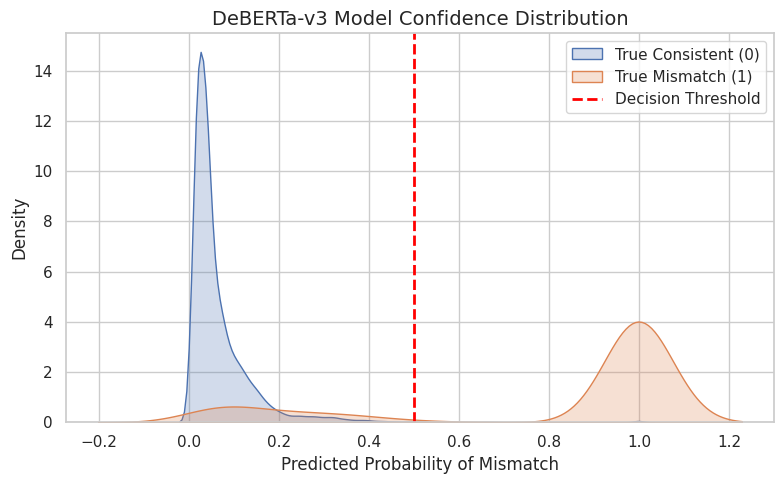

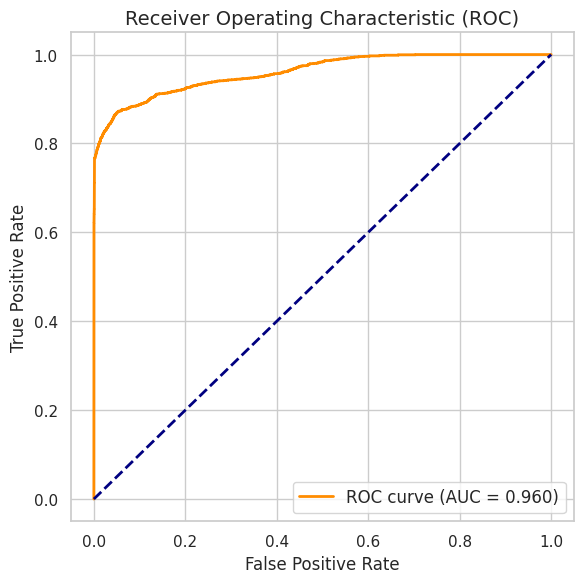

/tmp/ipykernel_7850/2458060941.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_mismatch.values, y=cat_mismatch.index, palette="Reds_r")


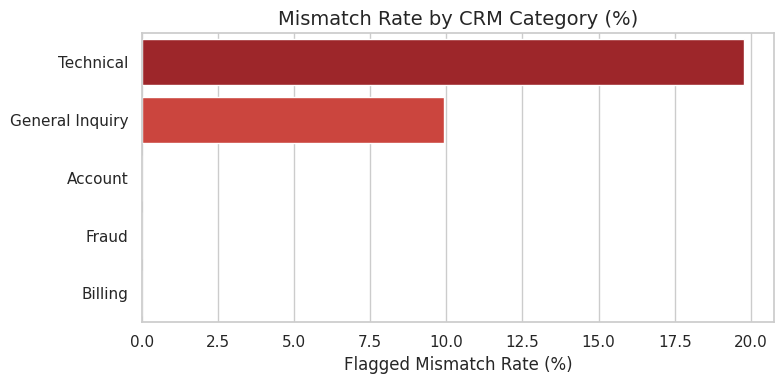


 📊 DETAILED CLASSIFICATION METRICS


,precision,recall,f1-score,support
Consistent,0.975000,0.999000,0.986000,17998.000000
Mismatch,0.984000,0.766000,0.862000,2002.000000
accuracy,0.975000,0.975000,0.975000,0.975000
macro avg,0.979000,0.882000,0.924000,20000.000000
weighted avg,0.976000,0.975000,0.974000,20000.000000



 🚨 HIGH-RISK EVIDENCE AUDIT: TOP 5 HIDDEN CRISES


Ticket_ID,Issue_Category,Priority_Level,Ticket_Channel,prob
TKT-101896,Technical,Low,Web Form,100.0%
TKT-118411,Technical,Low,Web Form,100.0%
TKT-113531,Technical,Low,Web Form,100.0%
TKT-116299,Technical,Low,Chat,100.0%
TKT-117330,Technical,Low,Web Form,100.0%


In [7]:

# ADVANCED METRICS, TABLES, & VISUALIZATIONS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from IPython.display import display
import json

sns.set_theme(style="whitegrid", palette="muted")


# GRAPH 1: Ablation Feature Weights

with open('outputs/ablation_table.json', 'r') as f:
    ablation_data = json.load(f)

features = list(ablation_data.keys())
weights = [abs(list(val.values())[0]) if isinstance(val, dict) else abs(val) for val in ablation_data.values()]

plt.figure(figsize=(9, 4))
sns.barplot(x=weights, y=features, palette="viridis")
plt.title("Ablation: Logistic Regression Feature Weights (Stage 1)")
plt.xlabel("Coefficient Magnitude")
plt.tight_layout()
plt.show()


# 1. Setup and Merge Data (AUTO-DETECT VERSION)

raw_df = pd.read_csv('customer_support_tickets.csv')
df_labels = pd.read_csv('outputs/labeled_tickets.csv')
df_preds = pd.read_csv('outputs/predictions.csv')

raw_df['Ticket_ID'] = raw_df['Ticket_ID'].astype(str)
df_labels['Ticket_ID'] = df_labels['Ticket_ID'].astype(str)
df_preds['Ticket_ID'] = df_preds['Ticket_ID'].astype(str)

# Auto-detect the ground-truth column in df_labels
possible_labels = ['label', 'mismatch_label', 'verdict', 'predicted', 'anomaly']
label_col_raw = next((c for c in possible_labels if c in df_labels.columns), df_labels.columns[-1])

# Auto-detect the prediction column in df_preds
pred_col_raw = 'predicted' if 'predicted' in df_preds.columns else 'prediction'

# Merge safely
merged = pd.merge(raw_df, df_labels[['Ticket_ID', label_col_raw]], on='Ticket_ID', how='inner')
merged = pd.merge(merged, df_preds[['Ticket_ID', 'prob', pred_col_raw]], on='Ticket_ID', how='inner')

# Force binary 0/1 format for charts regardless of what the CSV text says
def make_binary(val):
    if isinstance(val, str):
        return 1 if val.lower() in ['mismatch', 'hidden crisis', 'false alarm', '1', 'true'] else 0
    return int(val)

merged['TRUE_LABEL'] = merged[label_col_raw].apply(make_binary)
merged['PRED_LABEL'] = merged[pred_col_raw].apply(make_binary)

cat_col = 'Issue_Category' if 'Issue_Category' in merged.columns else 'Ticket Type'


# GRAPH 2: Pseudo-Label Mismatch Distribution

mismatches = merged['TRUE_LABEL'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(mismatches, labels=['Consistent (0)', 'Mismatch (1)'], autopct='%1.1f%%',
        colors=['#4c72b0', '#dd8452'], explode=[0, 0.1])
plt.title("Ground-Truth Pseudo-Label Distribution")
plt.show()


# GRAPH 3: Model Inference Confusion Matrix

cm = confusion_matrix(merged['TRUE_LABEL'], merged['PRED_LABEL'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Consistent', 'Mismatch'],
            yticklabels=['Consistent', 'Mismatch'])
plt.title("DeBERTa-v3 Inference Confusion Matrix")
plt.xlabel("Model Predicted Label")
plt.ylabel("True Pseudo-Label")
plt.tight_layout()
plt.show()


# GRAPH 4: Model Confidence Density (KDE)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=merged[merged['TRUE_LABEL']==0], x='prob', fill=True, color="#4c72b0", label='True Consistent (0)')
sns.kdeplot(data=merged[merged['TRUE_LABEL']==1], x='prob', fill=True, color="#dd8452", label='True Mismatch (1)')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
plt.title("DeBERTa-v3 Model Confidence Distribution", fontsize=14)
plt.xlabel("Predicted Probability of Mismatch", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


# GRAPH 5: Receiver Operating Characteristic (ROC Curve)

fpr, tpr, thresholds = roc_curve(merged['TRUE_LABEL'], merged['prob'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()


# GRAPH 6: Mismatch Rate by Ticket Category

cat_mismatch = merged.groupby(cat_col)['PRED_LABEL'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=cat_mismatch.values, y=cat_mismatch.index, palette="Reds_r")
plt.title("Mismatch Rate by CRM Category (%)", fontsize=14)
plt.xlabel("Flagged Mismatch Rate (%)", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()


# TABLE 1: Detailed Classification Report

print("\n" + "="*50)
print(" 📊 DETAILED CLASSIFICATION METRICS")
print("="*50)
report = classification_report(merged['TRUE_LABEL'], merged['PRED_LABEL'], target_names=['Consistent', 'Mismatch'], output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
display(report_df.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))


# TABLE 2: Top 5 Highest Confidence "Hidden Crises"

print("\n" + "="*50)
print(" 🚨 HIGH-RISK EVIDENCE AUDIT: TOP 5 HIDDEN CRISES")
print("="*50)

hidden_crises = merged[(merged['PRED_LABEL'] == 1) & (merged['Priority_Level'].isin(['Low', 'Medium']))]
top_crises = hidden_crises.sort_values(by='prob', ascending=False).head(5)

display_cols = ['Ticket_ID', cat_col, 'Priority_Level', 'prob']
if 'Ticket_Channel' in top_crises.columns:
    display_cols.insert(3, 'Ticket_Channel')

styled_df = top_crises[display_cols].style\
    .background_gradient(subset=['prob'], cmap='Reds')\
    .format({'prob': "{:.1%}"})\
    .hide(axis="index")

display(styled_df)